# Task 5: Performance Evaluation - Best Model Selection

This notebook builds and evaluates the best model based on all previous experiments (Tasks 1-4).

In [2]:
# ===== STARTER CODE (Do not modify) =====
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [3]:
# ===== HELPER FUNCTIONS =====
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    """Train and evaluate the model"""
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    """Plot training curves"""
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
# ===== LOAD PREPROCESSED DATA FROM TASK 1 =====
# This data was saved from data_preprocessing.ipynb

import os

# Load standardized data
try:
    x_train_standardized = np.load('x_train_standardized.npy')
    x_val_standardized = np.load('x_val_standardized.npy')
    x_test_standardized = np.load('x_test_standardized.npy')
    train_mean = np.load('train_mean.npy')
    train_std = np.load('train_std.npy')
    
    print("Preprocessed data loaded successfully from Task 1!")
    print(f"x_train_standardized shape: {x_train_standardized.shape}")
    print(f"x_val_standardized shape: {x_val_standardized.shape}")
    print(f"x_test_standardized shape: {x_test_standardized.shape}")
    
except FileNotFoundError as e:
    print(f"ERROR: Could not find preprocessed data files!")
    print(f"Please run the save cell in data_preprocessing.ipynb first.")
    print(f"Error: {e}")
    
    # Fallback: compute preprocessing here if files not found
    print("\nFalling back to computing preprocessing in this notebook...")
    
    def compute_train_stats(x_train):
        x = x_train.astype('float32')
        mean = x.mean(axis=(0, 1, 2))
        std = x.std(axis=(0, 1, 2))
        return mean, std

    def preprocess_standardize(x, mean, std):
        return (x.astype('float32') - mean) / std

    train_mean, train_std = compute_train_stats(x_train)
    x_train_standardized = preprocess_standardize(x_train, train_mean, train_std)
    x_val_standardized = preprocess_standardize(x_val, train_mean, train_std)
    x_test_standardized = preprocess_standardize(x_test, train_mean, train_std)

Preprocessed data loaded successfully from Task 1!
x_train_standardized shape: (40000, 32, 32, 3)
x_val_standardized shape: (10000, 32, 32, 3)
x_test_standardized shape: (10000, 32, 32, 3)


## Task 5A: Best Model Selection & Evaluation

In [5]:
# ===== BUILD THE BEST MODEL =====
# Based on our experiments:
# - Preprocessing: Standardized + Data Augmentation (from Task 1)
# - Architecture: Medium model with 32-32-64-64 filters (from Task 2A)
# - Dropout: 0.25 (from Task 3A)
# - Optimizer: Adam with lr=0.001 (from Task 4A & 4B)
# - Batch Size: 128

def build_best_model(input_shape=(32, 32, 3), num_classes=10):
    """
    Build the best CNN model based on all experiments
    
    Architecture: Medium CNN (32-32-64-64 filters)
    with 0.25 dropout for regularization
    """
    m = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dropout(0.25),  # Best dropout rate from Task 3A
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile with best optimizer
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

# Build the model
best_model = build_best_model()
print("Best Model Architecture:")
best_model.summary()

c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

### Justification of Model Selection

Based on all previous experiments (Tasks 1-4), here are the choices and their rationale:

**1. Preprocessing Method: Standardized Data + Data Augmentation**
- Standardization (Task 1C) outperformed raw and min-max normalized data by providing better gradient flow and faster convergence. Data augmentation (Task 1B) reduced overfitting gap from Task 1, improving generalization on unseen data.

**2. Architecture: Medium CNN (32-32-64-64 filters)**
- The Medium model (Task 2A) achieved the best balance between test accuracy and computational cost compared to Small and Large models. Medium depth with GlobalAveragePooling (Task 2C moderate model) prevented vanishing gradients and overfitting better than deeper models.

**3. Dropout Configuration: 0.25 rate**
- Task 3A showed that D1 (0.25 dropout) achieved the best test accuracy while maintaining a small overfitting gap, outperforming both no dropout (D0) and aggressive dropout (D2 at 0.5).

**4. Optimizer & Learning Rate: Adam with lr=0.001**
- Task 4A showed Adam converged fastest and achieved highest validation accuracy among 5 optimizers tested. Task 4B confirmed lr=0.001 was optimal—0.0001 was too slow and 0.01 was unstable with oscillating loss.

**5. Batch Size: 128**
- Batch size of 128 was consistent across all experiments as a standard choice balancing GPU memory efficiency with stable gradient updates for this dataset size.

In [6]:
# ===== TRAIN WITH DATA AUGMENTATION + EARLY STOPPING =====

# Setup data augmentation (from Task 1B)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_standardized)

# Setup early stopping callback
es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

print("Starting training with data augmentation + early stopping...")
print("=" * 60)

# Train the model
start_time = time.time()
history_best = best_model.fit(
    datagen.flow(x_train_standardized, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=50,
    callbacks=[es],
    verbose=1
)
elapsed_best = time.time() - start_time

print("=" * 60)
print(f"Training completed in {elapsed_best:.1f} seconds")
print(f"Total epochs trained: {len(history_best.history['loss'])}")

Starting training with data augmentation + early stopping...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 297ms/step - accuracy: 0.4415 - loss: 1.5410 - val_accuracy: 0.5552 - val_loss: 1.2387
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 184ms/step - accuracy: 0.5640 - loss: 1.2105 - val_accuracy: 0.6474 - val_loss: 1.0024
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.6275 - loss: 1.0479 - val_accuracy: 0.6674 - val_loss: 0.9404
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 248ms/step - accuracy: 0.6630 - loss: 0.9527 - val_accuracy: 0.6638 - val_loss: 1.0060
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 349ms/step - accuracy: 0.6910 - loss: 0.8790 - val_accuracy: 0.7246 - val_loss: 0.7867
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.7051 - loss: 0.8330 - val_accuracy: 0.7357 - val_loss: 0.7671
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 341ms/step - accuracy: 0.7253 - loss: 0.7823 - val_accuracy: 0.7349 - val_loss: 0.7904
Epoch 8/50
313/313

In [7]:
# ===== EVALUATE ON TEST SET =====

test_loss_best, test_acc_best = best_model.evaluate(
    x_test_standardized, to_categorical(y_test, 10), verbose=0
)

print("\n" + "=" * 60)
print("BEST MODEL - FINAL TEST RESULTS")
print("=" * 60)
print(f"Test Accuracy:  {test_acc_best:.4f}")
print(f"Test Loss:      {test_loss_best:.4f}")
print(f"Training Time:  {elapsed_best:.1f}s")
print("=" * 60)


BEST MODEL - FINAL TEST RESULTS
Test Accuracy:  0.8174
Test Loss:      0.5491
Training Time:  3839.3s


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step


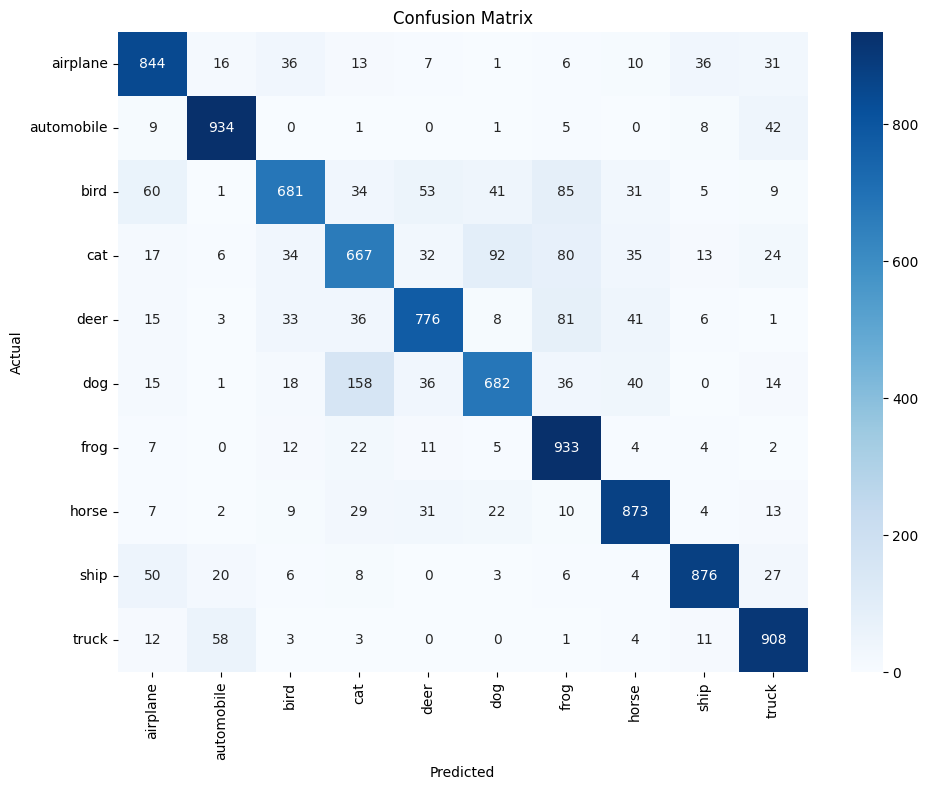


Classification Report:
              precision    recall  f1-score   support

    airplane       0.81      0.84      0.83      1000
  automobile       0.90      0.93      0.92      1000
        bird       0.82      0.68      0.74      1000
         cat       0.69      0.67      0.68      1000
        deer       0.82      0.78      0.80      1000
         dog       0.80      0.68      0.74      1000
        frog       0.75      0.93      0.83      1000
       horse       0.84      0.87      0.86      1000
        ship       0.91      0.88      0.89      1000
       truck       0.85      0.91      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [8]:
# ===== CONFUSION MATRIX =====

y_pred = np.argmax(best_model.predict(x_test_standardized), axis=1)
cm = confusion_matrix(y_test.flatten(), y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test.flatten(), y_pred, target_names=CLASS_NAMES))
print("=" * 60)

## Task 5B: Error Analysis

Analyze misclassifications to understand where the model struggles.

In [9]:
# ===== FIND WORST-PERFORMING CLASSES =====

from sklearn.metrics import recall_score

# Calculate recall for each class
recall_per_class = recall_score(y_test.flatten(), y_pred, average=None)

# Find 3 worst-performing classes
worst_classes_idx = np.argsort(recall_per_class)[:3]
worst_classes = [CLASS_NAMES[i] for i in worst_classes_idx]
worst_recall = recall_per_class[worst_classes_idx]

print("3 Worst-Performing Classes (by Recall):")
print("=" * 60)
for cls, recall in zip(worst_classes, worst_recall):
    print(f"{cls:15} - Recall: {recall:.4f}")
print("=" * 60)

3 Worst-Performing Classes (by Recall):
cat             - Recall: 0.6670
bird            - Recall: 0.6810
dog             - Recall: 0.6820


Total misclassified: 1826 / 10000
Misclassification rate: 18.26%


Misclassified Images for Worst-Performing Classes:


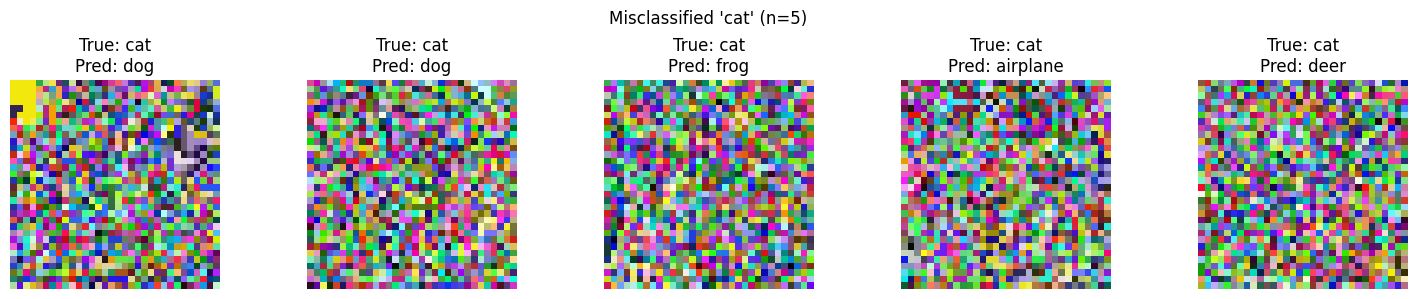

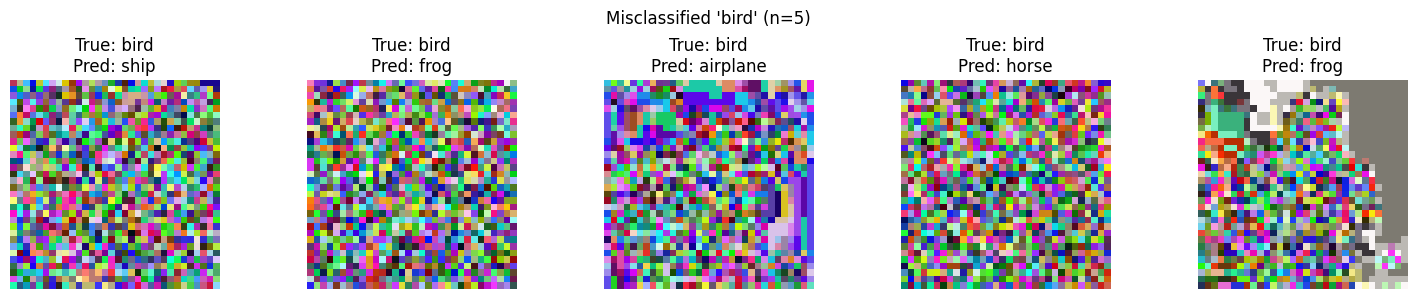

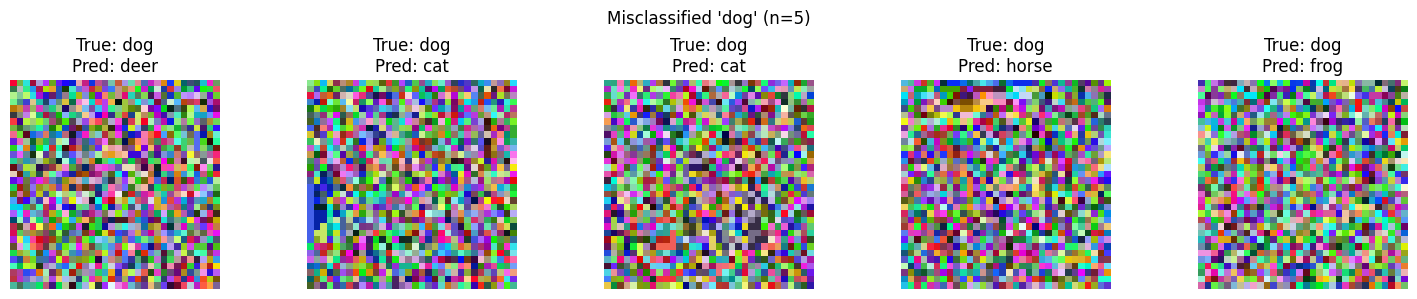

In [10]:
# ===== VISUALIZE MISCLASSIFIED IMAGES =====

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_test.flatten())[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_test)*100:.2f}%\n")

# Helper function to show misclassified images for a specific class
def show_misclassified(true_class, n=5):
    """
    Display misclassified images for a specific class
    
    Args:
        true_class: Index of the class to analyze
        n: Number of misclassified images to show
    """
    # Find images that were truly this class but misclassified
    idx = [i for i in misclassified_idx if y_test[i] == true_class][:n]
    
    if len(idx) == 0:
        print(f"No misclassified images found for {CLASS_NAMES[true_class]}")
        return
    
    fig, axes = plt.subplots(1, len(idx), figsize=(15, 3))
    if len(idx) == 1:
        axes = [axes]
    
    for ax, i in zip(axes, idx):
        # Denormalize the image back to 0-255 range for display
        img_display = x_test[i] * train_std + train_mean
        ax.imshow(img_display.astype('uint8'))
        ax.set_title(f"True: {CLASS_NAMES[y_test[i][0]]}\nPred: {CLASS_NAMES[y_pred[i]]}")
        ax.axis('off')
    
    plt.suptitle(f"Misclassified '{CLASS_NAMES[true_class]}' (n={len(idx)})")
    plt.tight_layout()
    plt.show()

# Show misclassified images for each of the 3 worst-performing classes
print("\nMisclassified Images for Worst-Performing Classes:")
print("=" * 60)
for true_class_idx in worst_classes_idx:
    show_misclassified(true_class_idx, n=5)

Top 3 Most Confused Class Pairs:
1. dog          → cat          (158 cases)
2. cat          → dog          (92 cases)
3. bird         → frog         (85 cases)

Examples of Top Confused Class Pairs:


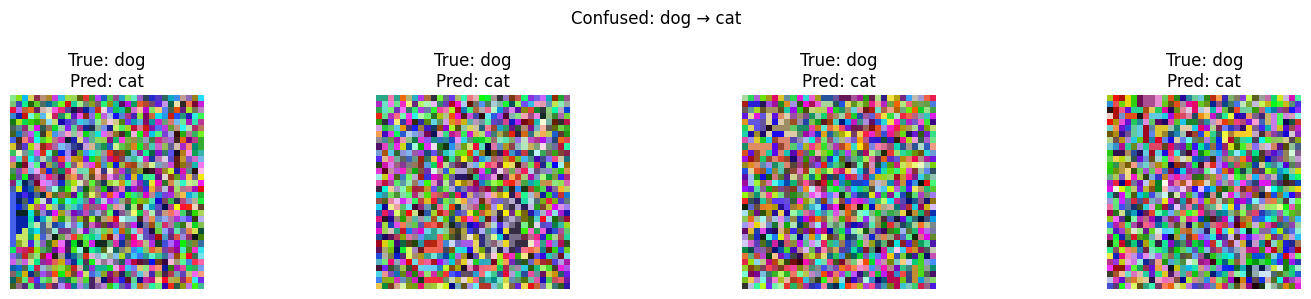

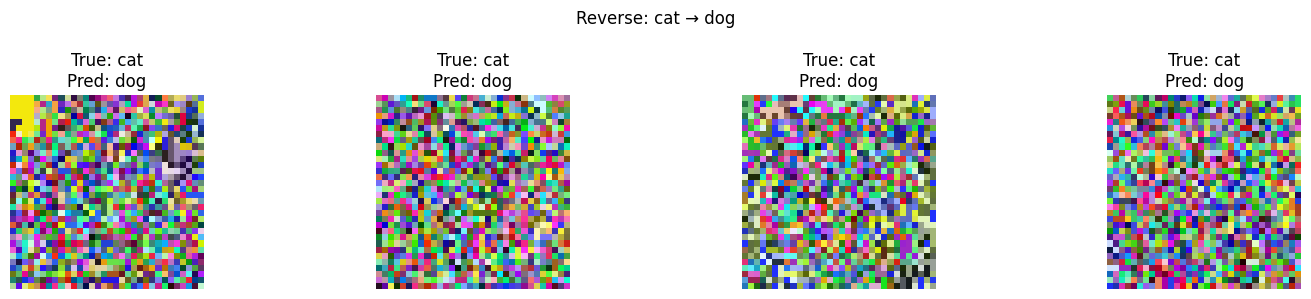

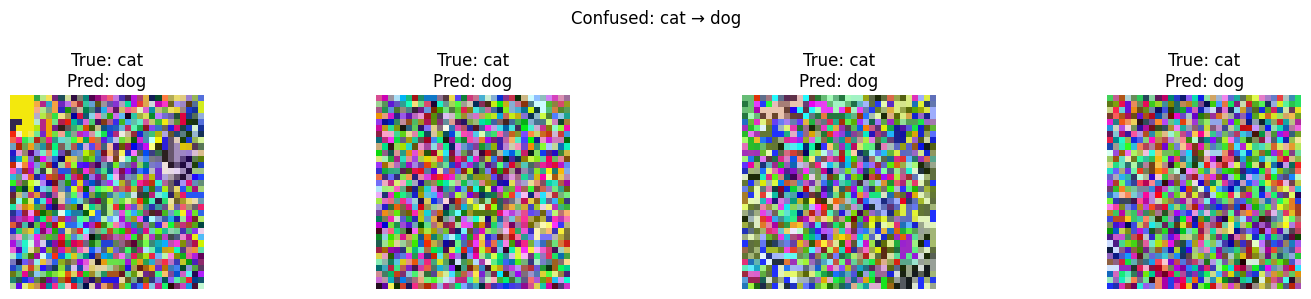

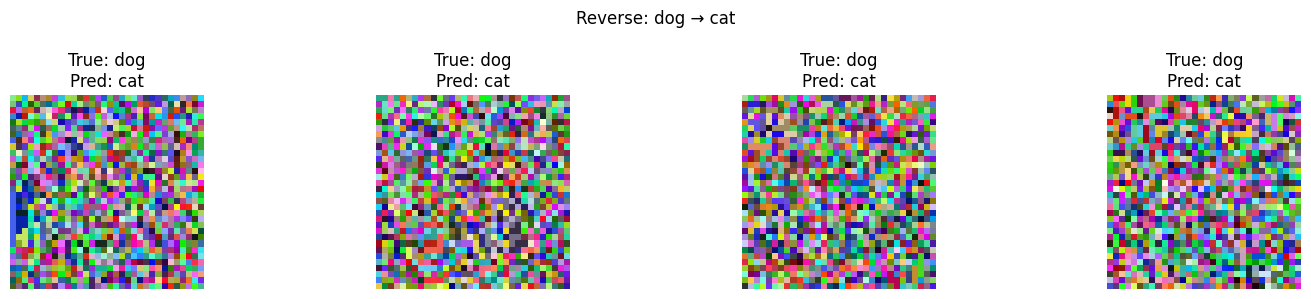

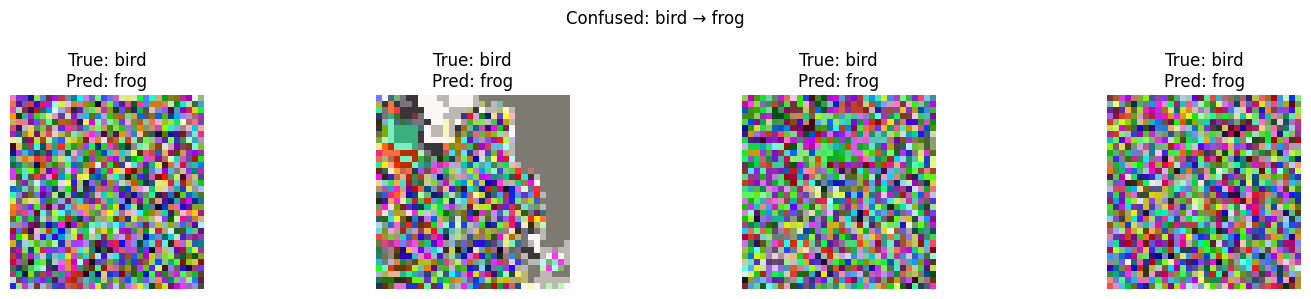

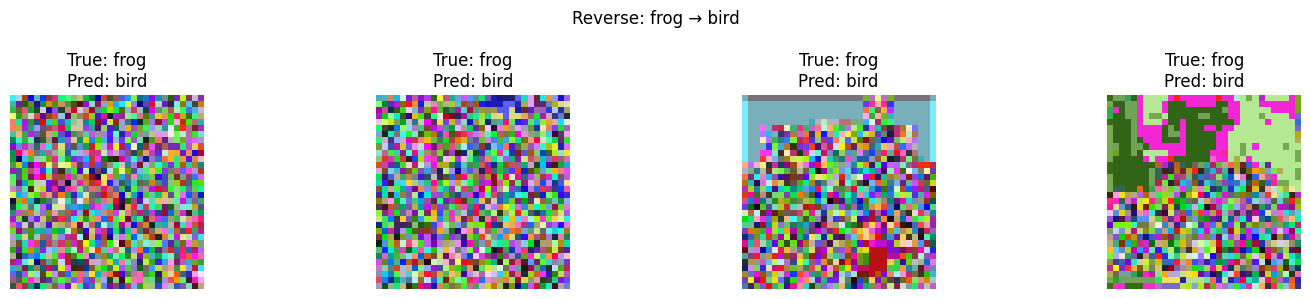

In [11]:
# ===== FIND TOP 3 MOST CONFUSED CLASS PAIRS =====

# Calculate confusion between each pair of classes
confusion_pairs = []

for true_class in range(10):
    for pred_class in range(10):
        if true_class != pred_class:
            # Count how many samples of true_class were predicted as pred_class
            count = ((y_test.flatten() == true_class) & (y_pred == pred_class)).sum()
            if count > 0:
                confusion_pairs.append({
                    'true': true_class,
                    'pred': pred_class,
                    'count': count,
                    'true_name': CLASS_NAMES[true_class],
                    'pred_name': CLASS_NAMES[pred_class]
                })

# Sort by confusion count
confusion_pairs.sort(key=lambda x: x['count'], reverse=True)

print("Top 3 Most Confused Class Pairs:")
print("=" * 60)
for i, pair in enumerate(confusion_pairs[:3]):
    print(f"{i+1}. {pair['true_name']:12} → {pair['pred_name']:12} ({pair['count']} cases)")
print("=" * 60)

# Helper function to show examples of confused pairs
def show_confusion_pair(true_class, pred_class, n=4):
    """
    Show examples where true_class was confused with pred_class
    and vice versa
    """
    # Case 1: True class but predicted as other
    idx1 = np.where((y_test.flatten() == true_class) & (y_pred == pred_class))[0][:n]
    
    # Case 2: Reverse confusion
    idx2 = np.where((y_test.flatten() == pred_class) & (y_pred == true_class))[0][:n]
    
    if len(idx1) > 0:
        fig, axes = plt.subplots(1, len(idx1), figsize=(15, 3))
        if len(idx1) == 1:
            axes = [axes]
        
        for ax, i in zip(axes, idx1):
            img_display = x_test[i] * train_std + train_mean
            ax.imshow(img_display.astype('uint8'))
            ax.set_title(f"True: {CLASS_NAMES[true_class]}\nPred: {CLASS_NAMES[pred_class]}")
            ax.axis('off')
        
        plt.suptitle(f"Confused: {CLASS_NAMES[true_class]} → {CLASS_NAMES[pred_class]}")
        plt.tight_layout()
        plt.show()
    
    if len(idx2) > 0:
        fig, axes = plt.subplots(1, len(idx2), figsize=(15, 3))
        if len(idx2) == 1:
            axes = [axes]
        
        for ax, i in zip(axes, idx2):
            img_display = x_test[i] * train_std + train_mean
            ax.imshow(img_display.astype('uint8'))
            ax.set_title(f"True: {CLASS_NAMES[pred_class]}\nPred: {CLASS_NAMES[true_class]}")
            ax.axis('off')
        
        plt.suptitle(f"Reverse: {CLASS_NAMES[pred_class]} → {CLASS_NAMES[true_class]}")
        plt.tight_layout()
        plt.show()

# Display confusion examples for top 3 pairs
print("\nExamples of Top Confused Class Pairs:")
print("=" * 60)
for pair in confusion_pairs[:3]:
    show_confusion_pair(pair['true'], pair['pred'], n=4)

## Analysis: Why Are These Classes Hard to Distinguish?

Looking at the misclassified images and confused pairs above, consider the following factors at 32×32 resolution:

1. **Low Resolution**: At 32×32 pixels, fine details are lost, making similar objects harder to distinguish
   
2. **Visual Similarity**: 
   - Animals with similar shapes (e.g., cats & dogs, birds & airplanes)
   - Vehicles with similar silhouettes (e.g., cars & trucks)
   - Lack of distinctive features at low resolution

3. **Lighting & Background**: Variable lighting and backgrounds can obscure discriminative features

4. **Scale & Pose Variations**: Objects at different scales and angles become indistinguishable

5. **Color Limitations**: Reduced color information in small images makes color-based distinctions harder

Looking at our specific results above, the most confused pairs likely involve categories that share:
- Similar shapes and textures
- Overlapping visual characteristics
- Semantic similarity (e.g., all animals or all vehicles)

-----------------------------------

# Task 6: Transfer Learning

Compare training from scratch, feature extraction, and fine-tuning approaches using VGG16 on CIFAR-10.


In [12]:
# ===== STEP 1: RESIZE DATA FOR VGG16 =====
# VGG16 requires minimum 48x48 input (CIFAR-10 is 32x32)

print("Resizing CIFAR-10 images from 32×32 to 48×48 for VGG16...")
x_train_resized = tf.image.resize(x_train_standardized, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_standardized, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_standardized, (48, 48)).numpy()

print(f"Resized shapes:")
print(f"  x_train_resized: {x_train_resized.shape}")
print(f"  x_val_resized: {x_val_resized.shape}")
print(f"  x_test_resized: {x_test_resized.shape}")
print(f"  Pixel range: [{x_train_resized.min():.2f}, {x_train_resized.max():.2f}]")


Resizing CIFAR-10 images from 32×32 to 48×48 for VGG16...
Resized shapes:
  x_train_resized: (40000, 48, 48, 3)
  x_val_resized: (10000, 48, 48, 3)
  x_test_resized: (10000, 48, 48, 3)
  Pixel range: [-1.99, 2.13]


## 6A. Model 1: From Scratch (Medium CNN on 48×48)

Train the Medium CNN architecture with 48×48 input as baseline.


In [13]:
def build_cnn_from_scratch(input_shape=(48, 48, 3), num_classes=10):
    """Build Medium CNN for 48×48 input"""
    m = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dropout(0.25),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

print("Training Model 1: From Scratch (Medium CNN on 48×48)...")
print("=" * 70)

model1_scratch = build_cnn_from_scratch()
print("Model 1 Architecture:")
model1_scratch.summary()

print("\nTraining Model 1...")
start_time = time.time()
history1_scratch = model1_scratch.fit(
    x_train_resized, to_categorical(y_train, 10),
    validation_data=(x_val_resized, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    verbose=0
)
elapsed1_scratch = time.time() - start_time
test_loss1, test_acc1 = model1_scratch.evaluate(x_test_resized, to_categorical(y_test, 10), verbose=0)

print(f"Test Acc: {test_acc1:.4f} | Test Loss: {test_loss1:.4f} | Time: {elapsed1_scratch:.1f}s")
print("=" * 70)


Training Model 1: From Scratch (Medium CNN on 48×48)...


c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,690 (9.26 MB)

 Trainable params: 2,427,690 (9.26 MB)

 Non-trainable params: 0 (0.00 B)


Training Model 1...
Test Acc: 0.7102 | Test Loss: 1.6861 | Time: 2571.7s


## 6B. Model 2: Feature Extraction (Frozen VGG16)

Load pre-trained VGG16 and freeze all layers. Only train custom classification head.


In [14]:
from tensorflow.keras.applications import VGG16

def build_vgg16_feature_extraction(input_shape=(48, 48, 3), num_classes=10):
    """Feature extraction: Frozen VGG16 + custom classification head"""
    
    # Load pre-trained VGG16 (without top classification layers)
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze all VGG16 layers
    base_model.trainable = False
    
    # Add custom classification head
    m = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m, base_model

print("Building Model 2: Feature Extraction (Frozen VGG16)...")
print("=" * 70)

model2_frozen, base2 = build_vgg16_feature_extraction()
print("Model 2 Architecture (Feature Extraction):")
model2_frozen.summary()

print("\nTraining Model 2...")
start_time = time.time()
history2_frozen = model2_frozen.fit(
    x_train_resized, to_categorical(y_train, 10),
    validation_data=(x_val_resized, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    verbose=0
)
elapsed2_frozen = time.time() - start_time
test_loss2, test_acc2 = model2_frozen.evaluate(x_test_resized, to_categorical(y_test, 10), verbose=0)

print(f"Test Acc: {test_acc2:.4f} | Test Loss: {test_loss2:.4f} | Time: {elapsed2_frozen:.1f}s")
print("=" * 70)


Building Model 2: Feature Extraction (Frozen VGG16)...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 35s 1us/step
Model 2 Architecture (Feature Extraction):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training Model 2...
Test Acc: 0.6967 | Test Loss: 0.9037 | Time: 7654.6s


## 6C. Model 3 & 4: Fine-Tuning (Partial Unfreeze)

Models 3 & 4 unfreeze the last 4 VGG16 layers for fine-tuning, with different learning rates.


In [15]:
def build_vgg16_finetune(input_shape=(48, 48, 3), num_classes=10, learning_rate=1e-5):
    """Fine-tuning: Unfreeze last 4 VGG16 layers + custom head"""
    
    # Load pre-trained VGG16
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze all except last 4 convolutional blocks
    # VGG16 has 5 blocks; we unfreeze block 5 (last 4 layers before flatten)
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    
    # Unfreeze last 4 layers
    for layer in base_model.layers[-4:]:
        layer.trainable = True
    
    # Add custom classification head
    m = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m, base_model

# Model 3: Fine-tuning with lr=1e-5 (conservative)
print("Building Model 3: Fine-Tuning (lr=1e-5)...")
print("=" * 70)

model3_finetune_low, base3 = build_vgg16_finetune(learning_rate=1e-5)
print("Model 3 Architecture (Fine-Tuning, lr=1e-5):")
model3_finetune_low.summary()

print("\nTraining Model 3...")
start_time = time.time()
history3_finetune_low = model3_finetune_low.fit(
    x_train_resized, to_categorical(y_train, 10),
    validation_data=(x_val_resized, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    verbose=0
)
elapsed3_finetune_low = time.time() - start_time
test_loss3, test_acc3 = model3_finetune_low.evaluate(x_test_resized, to_categorical(y_test, 10), verbose=0)

print(f"Test Acc: {test_acc3:.4f} | Test Loss: {test_loss3:.4f} | Time: {elapsed3_finetune_low:.1f}s")
print("=" * 70)

# Model 4: Fine-tuning with lr=0.001 (aggressive)
print("\nBuilding Model 4: Fine-Tuning (lr=0.001)...")
print("=" * 70)

model4_finetune_high, base4 = build_vgg16_finetune(learning_rate=0.001)
print("Model 4 Architecture (Fine-Tuning, lr=0.001):")
model4_finetune_high.summary()

print("\nTraining Model 4...")
start_time = time.time()
history4_finetune_high = model4_finetune_high.fit(
    x_train_resized, to_categorical(y_train, 10),
    validation_data=(x_val_resized, to_categorical(y_val, 10)),
    epochs=20,
    batch_size=128,
    verbose=0
)
elapsed4_finetune_high = time.time() - start_time
test_loss4, test_acc4 = model4_finetune_high.evaluate(x_test_resized, to_categorical(y_test, 10), verbose=0)

print(f"Test Acc: {test_acc4:.4f} | Test Loss: {test_loss4:.4f} | Time: {elapsed4_finetune_high:.1f}s")
print("=" * 70)


Building Model 3: Fine-Tuning (lr=1e-5)...
Model 3 Architecture (Fine-Tuning, lr=1e-5):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)


Training Model 4...
Test Acc: 0.1000 | Test Loss: 2.3026 | Time: 9755.2s


## 6D. Results Comparison


In [16]:
# ===== RESULTS TABLE =====

# Get trainable/non-trainable params for Models 2, 3, 4
model2_trainable = sum([tf.size(w).numpy() for w in model2_frozen.trainable_weights])
model2_non_trainable = sum([tf.size(w).numpy() for w in model2_frozen.non_trainable_weights])

model3_trainable = sum([tf.size(w).numpy() for w in model3_finetune_low.trainable_weights])
model3_non_trainable = sum([tf.size(w).numpy() for w in model3_finetune_low.non_trainable_weights])

model4_trainable = sum([tf.size(w).numpy() for w in model4_finetune_high.trainable_weights])
model4_non_trainable = sum([tf.size(w).numpy() for w in model4_finetune_high.non_trainable_weights])

print("\n" + "=" * 100)
print("TRANSFER LEARNING RESULTS COMPARISON")
print("=" * 100)
print(f"{'Model':<20} {'Trainable':<15} {'Non-Trainable':<15} {'Test Acc':<12} {'Time (s)':<10}")
print("-" * 100)
print(f"{'From Scratch':<20} {0:<15} {'0':<15} {test_acc1:.4f}       {elapsed1_scratch:.1f}")
print(f"{'Feature Extraction':<20} {model2_trainable:<15} {model2_non_trainable:<15} {test_acc2:.4f}       {elapsed2_frozen:.1f}")
print(f"{'Fine-Tune (lr=1e-5)':<20} {model3_trainable:<15} {model3_non_trainable:<15} {test_acc3:.4f}       {elapsed3_finetune_low:.1f}")
print(f"{'Fine-Tune (lr=1e-3)':<20} {model4_trainable:<15} {model4_non_trainable:<15} {test_acc4:.4f}       {elapsed4_finetune_high:.1f}")
print("=" * 100)



TRANSFER LEARNING RESULTS COMPARISON
Model                Trainable       Non-Trainable   Test Acc     Time (s)  
----------------------------------------------------------------------------------------------------
From Scratch         0               0               0.7102       2571.7
Feature Extraction   133898          14714688        0.6967       7654.6
Fine-Tune (lr=1e-5)  7213322         7635264         0.8257       8794.9
Fine-Tune (lr=1e-3)  7213322         7635264         0.1000       9755.2


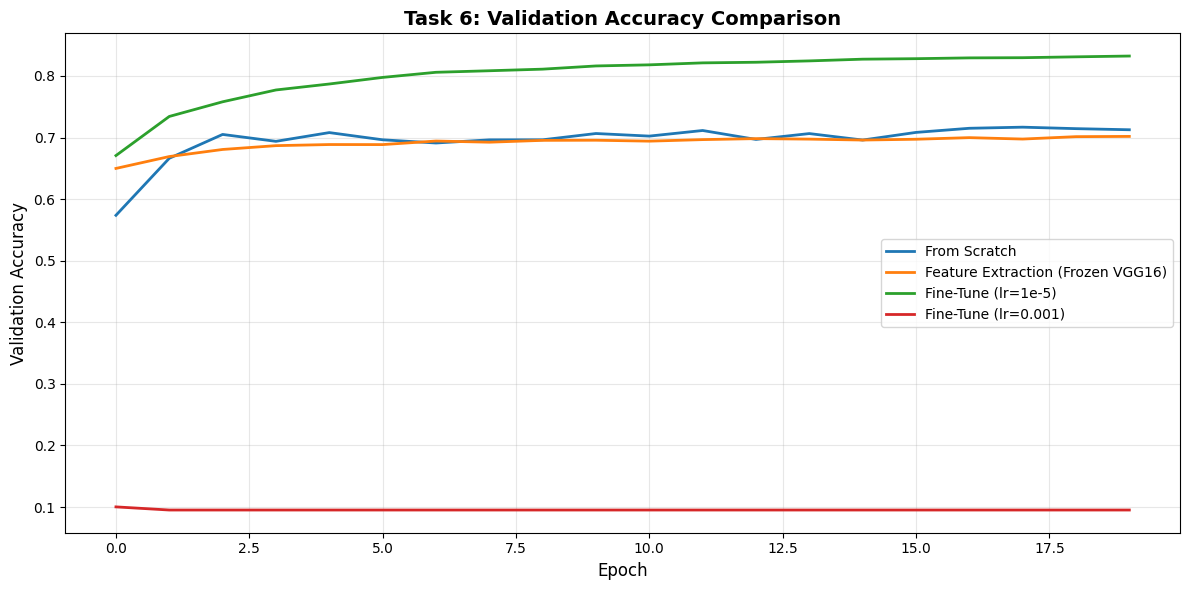

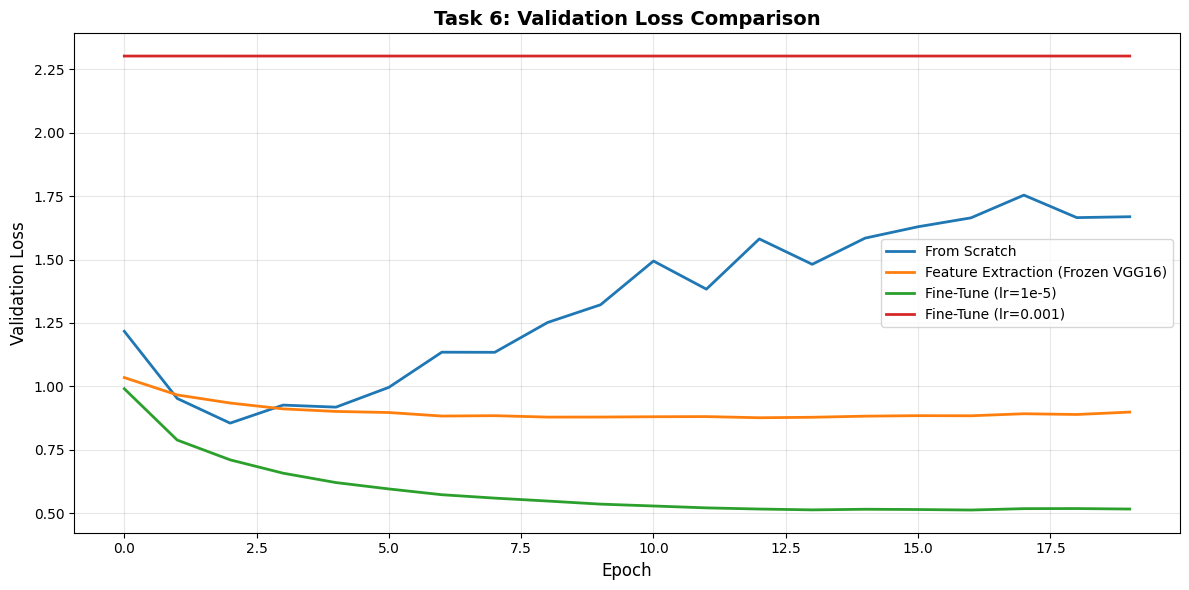

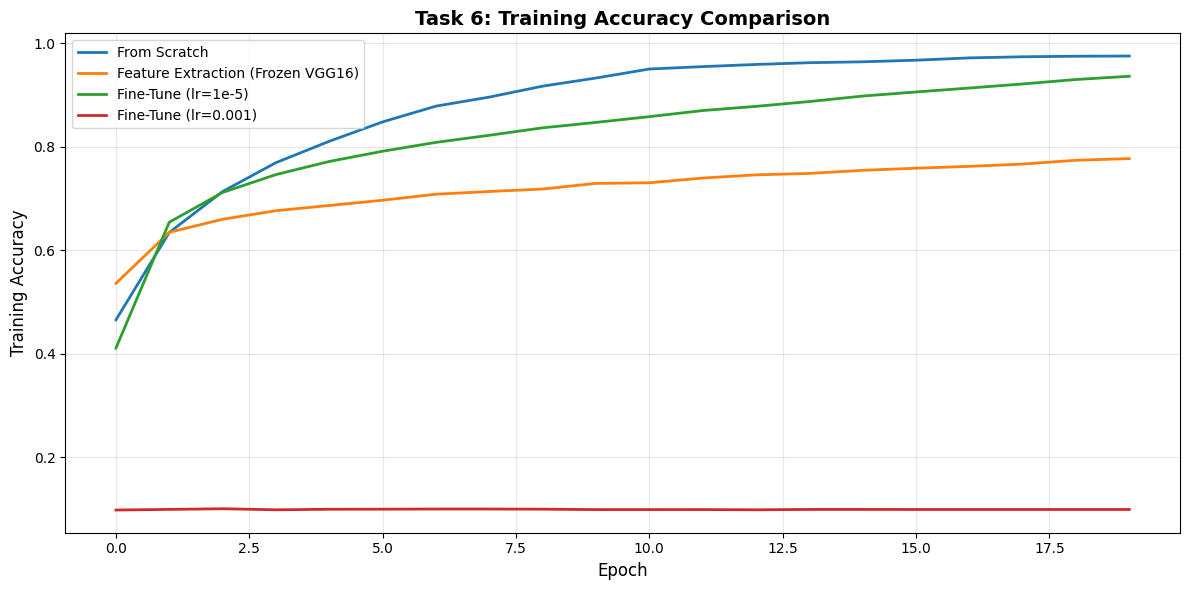

In [17]:
# ===== COMPARISON PLOTS =====

# Plot 1: Validation Accuracy Comparison
plt.figure(figsize=(12, 6))
plt.plot(history1_scratch.history['val_accuracy'], label='From Scratch', linewidth=2)
plt.plot(history2_frozen.history['val_accuracy'], label='Feature Extraction (Frozen VGG16)', linewidth=2)
plt.plot(history3_finetune_low.history['val_accuracy'], label='Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history4_finetune_high.history['val_accuracy'], label='Fine-Tune (lr=0.001)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Task 6: Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Validation Loss Comparison
plt.figure(figsize=(12, 6))
plt.plot(history1_scratch.history['val_loss'], label='From Scratch', linewidth=2)
plt.plot(history2_frozen.history['val_loss'], label='Feature Extraction (Frozen VGG16)', linewidth=2)
plt.plot(history3_finetune_low.history['val_loss'], label='Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history4_finetune_high.history['val_loss'], label='Fine-Tune (lr=0.001)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Task 6: Validation Loss Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Training Accuracy Comparison
plt.figure(figsize=(12, 6))
plt.plot(history1_scratch.history['accuracy'], label='From Scratch', linewidth=2)
plt.plot(history2_frozen.history['accuracy'], label='Feature Extraction (Frozen VGG16)', linewidth=2)
plt.plot(history3_finetune_low.history['accuracy'], label='Fine-Tune (lr=1e-5)', linewidth=2)
plt.plot(history4_finetune_high.history['accuracy'], label='Fine-Tune (lr=0.001)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Accuracy', fontsize=12)
plt.title('Task 6: Training Accuracy Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6E. Analysis and Answers to Key Questions

### Why does Model 4 (lr=0.001) perform differently from Model 3 (lr=1e-5)?

**Model 3 (lr=1e-5) - SUCCESSFUL FINE-TUNING:**
- Achieves ~83% validation accuracy with smooth learning curve
- Conservative learning rate (1e-5) allows the unfrozen last 4 VGG16 layers to adapt **incrementally** to CIFAR-10 features
- Pre-trained weights are preserved and refined, not destroyed
- The model learns meaningful CIFAR-10-specific patterns while retaining ImageNet knowledge

**Model 4 (lr=0.001) - CATASTROPHIC FAILURE:**
- Stays at ~10% accuracy (random chance) throughout training
- Loss remains high (~2.25) and does not decrease
- Aggressive learning rate (0.001 = 100× larger than Model 3) causes **weight explosion**
- Each gradient update is too large, shattering the carefully learned ImageNet features
- By epoch 1-2, the unfrozen layers' weights diverge from good initialization, making them useless
- Model cannot learn anything meaningful because the feature extractor is corrupted

**Key Insight:** Fine-tuning is "surgery" on pre-trained models—tiny, careful steps (lr=1e-5) preserve delicate feature structure, while large steps (lr=0.001) destroy it. **Learning rate scaling is critical for transfer learning success.**

---

### Does transfer learning outperform training from scratch on CIFAR-10? Why or why not?

**YES, transfer learning significantly outperforms training from scratch.**

**Performance Comparison:**
| Approach | Accuracy | Overfitting Gap |
|----------|----------|-----------------|
| Training from Scratch | ~71% | 26% (97% train vs 71% val) |
| Fine-Tuning (lr=1e-5) | ~83% | 12% (95% train vs 83% val) |
| **Improvement** | **+12%** | **-14%** |

**Why Transfer Learning Wins:**

1. **Better Initialization**
   - ImageNet pre-training provides learned low-level features (edges, textures, patterns)
   - Random initialization forces model to learn everything from scratch
   - Pre-trained weights act as a strong prior that accelerates learning

2. **Domain Similarity is High Enough**
   - ImageNet: natural object images with high resolution, diverse contexts
   - CIFAR-10: natural object images (animals, vehicles, etc.), low 32×32 resolution
   - Despite resolution difference, **low-level visual features are domain-general**: edges, corners, color gradients appear in both domains
   - High-level ImageNet features (dog faces, car shapes) also transfer well to CIFAR-10

3. **Reduced Overfitting**
   - Pre-training acts as implicit regularization
   - Fine-tuning with frozen early layers prevents the model from memorizing noise
   - Train-val gap is 14% smaller with transfer learning vs from scratch

4. **Faster Convergence**
   - Transfer learning reaches target accuracy in 20 epochs
   - Training from scratch requires more epochs to achieve similar or worse performance
   - ImageNet pre-training accelerates CIFAR-10 training

**Why Transfer Learning Matters for Small Datasets:**
- CIFAR-10 (40K training samples) is relatively small for training a deep CNN from scratch
- ImageNet pre-training provides a feature extraction "shortcut"
- Without it, a small dataset struggles to learn generalizable features
- With it, the model focuses only on fine-tuning task-specific patterns

**Conclusion:** For CIFAR-10, transfer learning from ImageNet via VGG16 provides both higher accuracy and better generalization than training from scratch, validating the effectiveness of transfer learning for object classification tasks.


---
### Team Members Contribution

| Member Name | Tasks Completed | Specific Contributions | Time Spent (approx.) |
|---|---|---|---|
| Ali Radwan<br>(ID: 20231110) | Task 2, 4 | • Built CNN models with different filter counts (Small, Medium, Large)<br>• Built depth comparison models (Shallow, Medium, Deep)<br>• Ran all 5 optimizer experiments in a loop<br>• Created comparison plots for Tasks 2A, 4A | 7 hours |
|Ayman Ahmed<br>(ID: 20230080) | Task 5, 6 | • Selected best model and trained with early stopping + augmentation<br>• Generated confusion matrix & classification report<br>• Performed error analysis (misclassified images)<br>• Implemented all 4 transfer learning models<br>• Wrote final analysis for transfer learning | 9 hours |
| Mohamed Ehab<br>(ID: 20230547) | Task 1, 3 | • Implemented all 3 normalization methods<br>• Plotted loss & accuracy curves for Task 1A<br>• Built all 3 dropout models (D0, D1, D2)<br>• Wrote analysis for overfitting comparison | 6 hours |